# Cardiff Automated Valuation Model 

This notebook contains the final dissertation workflow for Cardiff residential property price modelling (2022–2026):

1. Load and clean HM Land Registry Price Paid Data.
2. Match Cardiff postcodes and coordinates.
3. Engineer spatial features: city-centre distance, school, transport, greenspace and flood risk.
4. Engineer a 12-month crime count within 1 km.
5. Match EPC floor area and habitable-room information.
6. Adjust historical prices using Cardiff UKHPI by property type and create decimal year.
7. Compare Model A (without EPC) and Model B (with EPC).
8. Compare Random Forest and XGBoost, select the final model, and interpret it.
9. Export the trained model and lookup files.
10. Run the property-value input prototype and local SHAP explanation.



# 1. Setup


## 1.1 Imports


In [1]:
import gc
import json
import shutil
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import shap

from matplotlib.ticker import FuncFormatter
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    make_scorer,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import (
    KFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor


## 1.2 Project paths


In [ ]:
PROJECT_ROOT = Path.cwd()

# Raw/reference inputs
pp_folder = PROJECT_ROOT / "dataFile/pp"
postcode_path = PROJECT_ROOT / "postcode/01_Cardiff_Postcode.csv"
school_path = PROJECT_ROOT / "spatial/(School)maintained_schools_wg.gpkg"
transport_path = PROJECT_ROOT / "spatial/(Transport)NaPTAN_wales_feb_26.gpkg"
greenspace_path = (
    PROJECT_ROOT
    / "Data/OS Open Greenspace (ESRI Shape File) ST/data/ST_GreenspaceSite.shp"
)
flood_folder = PROJECT_ROOT / "Data/Flood"
river_path = flood_folder / "NRW_FLOOD_RISK_FROM_RIVERS.gpkg"
sea_path = flood_folder / "NRW_FLOOD_RISK_FROM_SEA.gpkg"
surface_path = (
    flood_folder
    / "NRW_FLOOD_RISK_FROM_SURFACE_WATER_SMALL_WATERCOURSES.gpkg"
)
crime_folder = PROJECT_ROOT / "Data/(Crime)dataPolice"
epc_path = PROJECT_ROOT / "latest/epc.csv"
hpi_path = (
    PROJECT_ROOT
    / "latest/ukhpi-property-type-hpi-cardiff-from-2022-01-01-to-2026-06-01.csv"
)

# Derived/checkpoint outputs
latest_folder = PROJECT_ROOT / "latest"
latest_folder.mkdir(parents=True, exist_ok=True)

spatial_crime_path = (
    latest_folder
    / "house_gdf_school_transport_green_flood_crime_address.gpkg"
)
epc_output_path = latest_folder / "houses_epc_2022_2026.gpkg"
modelling_data_path = latest_folder / "Data_for_Modelling.gpkg"
crime_gpkg_path = crime_folder / "crime.gpkg"

# Final model outputs
model_folder = latest_folder / "model"
model_folder.mkdir(parents=True, exist_ok=True)


# 2. Price Paid Data and Cardiff Locations


## 2.1 Load Price Paid Data


In [3]:
pp_files = sorted(pp_folder.rglob("*.csv"))

if not pp_files:
    raise FileNotFoundError(f"No CSV files found in {pp_folder}")

pp_df = pd.concat(
    [
        pd.read_csv(file, header=None, low_memory=False)
        for file in pp_files
    ],
    ignore_index=True
)


ppd_column_names = [
    "transaction_id",
    "price",
    "date_of_transfer",
    "postcode",
    "property_type",
    "old_new",
    "duration",
    "paon",
    "saon",
    "street",
    "locality",
    "town_city",
    "district",
    "county",
    "ppd_category_type",
    "record_status"
]

pp_df.columns = ppd_column_names


## 2.2 Clean and filter Cardiff transactions


In [4]:
pp_df["price"] = pd.to_numeric(
    pp_df["price"],
    errors="coerce"
)

pp_df["date_of_transfer"] = pd.to_datetime(
    pp_df["date_of_transfer"],
    errors="coerce"
)

for column in ["town_city", "district", "county"]:
    pp_df[column] = (
        pp_df[column]
        .astype("string")
        .str.upper()
        .str.strip()
    )

pp_df = pp_df[
    [
        "price",
        "date_of_transfer",
        "postcode",
        "property_type",
        "old_new",
        "duration",
         "paon",
        "saon",
        "street",
        "locality",
        "town_city",
        "district",
        "county",
        "ppd_category_type"
    ]
].copy()

pp_df = pp_df.dropna(
    subset=["price", "date_of_transfer", "postcode"]
)

pp_df = pp_df[pp_df["price"] > 0].copy()

pp_df["year"] = pp_df["date_of_transfer"].dt.year
pp_df["month"] = pp_df["date_of_transfer"].dt.month


pp_df_clean = pp_df[
    (pp_df["town_city"] == "CARDIFF")
    & (pp_df["district"] == "CARDIFF")
    & (pp_df["county"] == "CARDIFF")
].copy()

pp_df_clean = pp_df_clean.reset_index(drop=True)


## 2.3 Load and standardise postcode coordinates


In [5]:
postcode_df = pd.read_csv(
    postcode_path,
    low_memory=False
)

postcode_df = postcode_df.rename(
    columns={
        "pcd": "postcode",
        "long": "longitude",
        "lat": "latitude"
    }
)


def clean_postcode(postcode_series):
    return (
        postcode_series
        .astype("string")
        .str.upper()
        .str.strip()
        .str.replace(r"\s+", "", regex=True)
    )


pp_df_clean["postcode"] = clean_postcode(
    pp_df_clean["postcode"]
)

postcode_df["postcode"] = clean_postcode(
    postcode_df["postcode"]
)

pp_df_clean["postcode_district"] = (
    pp_df_clean["postcode"]
    .str.extract(
        r"^([A-Z]{1,2}\d[A-Z\d]?)",
        expand=False
    )
)

postcode_df_clean = (
    postcode_df[
        ["postcode", "longitude", "latitude"]
    ]
    .dropna(
        subset=["postcode", "longitude", "latitude"]
    )
    .drop_duplicates(
        subset="postcode",
        keep="first"
    )
    .reset_index(drop=True)
)


## 2.4 Check postcode matching and retain matched transactions


In [6]:
postcode_matches = pp_df_clean["postcode"].isin(
    postcode_df_clean["postcode"]
)

postcode_match_summary = pd.DataFrame(
    {
        "measure": [
            "Cardiff transactions",
            "Matching transactions",
            "Non-matching transactions"
        ],
        "rows": [
            len(pp_df_clean),
            int(postcode_matches.sum()),
            int((~postcode_matches).sum())
        ]
    }
)

postcode_match_summary


pp_df_clean = (
    pp_df_clean.loc[postcode_matches]
    .copy()
    .reset_index(drop=True)
)


## 2.5 Merge coordinates


In [7]:
house_df = pp_df_clean.merge(
    postcode_df_clean,
    on="postcode",
    how="left",
    validate="many_to_one"
)

house_df = (
    house_df
    .dropna(subset=["longitude", "latitude"])
    .reset_index(drop=True)
)

house_df["houses_id"] = house_df.index


## 2.6 Create price and Cardiff-centre distance features


In [8]:
cardiff_latitude = 51.4816
cardiff_longitude = -3.1791


def haversine(
    latitude_1,
    longitude_1,
    latitude_2,
    longitude_2
):
    earth_radius_km = 6371

    latitude_1 = np.radians(latitude_1)
    longitude_1 = np.radians(longitude_1)
    latitude_2 = np.radians(latitude_2)
    longitude_2 = np.radians(longitude_2)

    latitude_difference = latitude_2 - latitude_1
    longitude_difference = longitude_2 - longitude_1

    a = (
        np.sin(latitude_difference / 2) ** 2
        + np.cos(latitude_1)
        * np.cos(latitude_2)
        * np.sin(longitude_difference / 2) ** 2
    )

    c = 2 * np.arctan2(
        np.sqrt(a),
        np.sqrt(1 - a)
    )

    return earth_radius_km * c


def create_distance_band(distance_km):
    if distance_km < 2:
        return "0-2km"
    if distance_km < 5:
        return "2-5km"
    if distance_km < 10:
        return "5-10km"
    if distance_km <= 20:
        return "10-20km"
    return "20km+"


house_df["log_price"] = np.log(
    house_df["price"]
)

house_df["distance_to_cardiff_centre_km"] = haversine(
    house_df["latitude"],
    house_df["longitude"],
    cardiff_latitude,
    cardiff_longitude
)

house_df["distance_band"] = (
    house_df["distance_to_cardiff_centre_km"]
    .apply(create_distance_band)
)


## 2.7 Create projected house GeoDataFrame


In [9]:
house_gdf = gpd.GeoDataFrame(
    house_df,
    geometry=gpd.points_from_xy(
        house_df["longitude"],
        house_df["latitude"]
    ),
    crs="EPSG:4326"
)

house_gdf = house_gdf.to_crs(
    "EPSG:27700"
)


# 3. Spatial Feature Engineering


## 3.1 Helper for nearest spatial joins


In [10]:
def keep_one_nearest_record(
    joined_gdf,
    distance_column
):
    return (
        joined_gdf
        .sort_values(
            ["houses_id", distance_column],
            na_position="last"
        )
        .drop_duplicates(
            subset="houses_id",
            keep="first"
        )
        .reset_index(drop=True)
    )


## 3.2 Nearest school


In [11]:
school_gdf = gpd.read_file(
    school_path
)

cardiff_school_gdf = (
    school_gdf[
        school_gdf["local_authority"] == "Cardiff"
    ]
    .copy()
    .to_crs(house_gdf.crs)
)

house_gdf_school = gpd.sjoin_nearest(
    house_gdf,
    cardiff_school_gdf[
        [
            "school_code",
            "school_name",
            "sector",
            "school_type",
            "pupils",
            "geometry"
        ]
    ],
    how="left",
    distance_col="distance_to_nearest_school_m"
)

house_gdf_school = keep_one_nearest_record(
    house_gdf_school,
    "distance_to_nearest_school_m"
)


## 3.3 Nearest transport stop


In [12]:
transport_gdf = gpd.read_file(
    transport_path
)

transport_gdf = (
    transport_gdf[
        transport_gdf["status"] == "active"
    ][
        [
            "atcocode",
            "commonname",
            "stoptype",
            "busstoptype",
            "status",
            "geometry"
        ]
    ]
    .copy()
    .to_crs(house_gdf.crs)
)

house_gdf_school = house_gdf_school.drop(
    columns="index_right",
    errors="ignore"
)

house_gdf_school_transport = gpd.sjoin_nearest(
    house_gdf_school,
    transport_gdf,
    how="left",
    distance_col="distance_to_nearest_transport_m"
)

house_gdf_school_transport = keep_one_nearest_record(
    house_gdf_school_transport,
    "distance_to_nearest_transport_m"
)


/Users/paingminnaing/Library/Mobile Documents/com~apple~CloudDocs/COMSCO/Dissertation/Submission/sklearn-env/lib/python3.13/site-packages/pyogrio/raw.py:200: RuntimeWarning: Field format 'TIMESTAMP' not supported
  return ogr_read(
/Users/paingminnaing/Library/Mobile Documents/com~apple~CloudDocs/COMSCO/Dissertation/Submission/sklearn-env/lib/python3.13/site-packages/pyogrio/raw.py:200: RuntimeWarning: geometry column 'creationdatetime' of type 'TIMESTAMP' ignored
  return ogr_read(
/Users/paingminnaing/Library/Mobile Documents/com~apple~CloudDocs/COMSCO/Dissertation/Submission/sklearn-env/lib/python3.13/site-packages/pyogrio/raw.py:200: RuntimeWarning: geometry column 'modificationdatetime' of type 'TIMESTAMP' ignored
  return ogr_read(


## 3.4 Nearest greenspace


In [13]:
greenspace_gdf = gpd.read_file(
    greenspace_path
)

greenspace_sites = (
    greenspace_gdf[
        [
            "function",
            "distName1",
            "geometry"
        ]
    ]
    .rename(
        columns={
            "function": "greenspace_function",
            "distName1": "greenspace_name"
        }
    )
    .copy()
    .to_crs(house_gdf.crs)
)

house_gdf_school_transport = (
    house_gdf_school_transport.drop(
        columns="index_right",
        errors="ignore"
    )
)

house_gdf_school_transport_green = gpd.sjoin_nearest(
    house_gdf_school_transport,
    greenspace_sites,
    how="left",
    distance_col="nearest_greenspace_distance_m"
)

house_gdf_school_transport_green = keep_one_nearest_record(
    house_gdf_school_transport_green,
    "nearest_greenspace_distance_m"
)


## 3.5 Flood-risk indicators


In [14]:
def add_flood_risk_flag(
    houses_gdf,
    flood_path,
    flag_column
):
    houses_gdf = houses_gdf.copy()

    flood_gdf = (
        gpd.read_file(flood_path)
        .to_crs(houses_gdf.crs)
    )

    flood_gdf = flood_gdf[
        flood_gdf.geometry.notna()
        & ~flood_gdf.geometry.is_empty
    ].copy()

    cardiff_area = (
        houses_gdf.geometry
        .buffer(5000)
        .union_all()
    )

    flood_gdf = flood_gdf[
        flood_gdf.geometry.intersects(cardiff_area)
    ].copy()

    houses_temp = houses_gdf[
        ["houses_id", "geometry"]
    ].copy()

    joined = gpd.sjoin(
        houses_temp,
        flood_gdf[["geometry"]],
        how="inner",
        predicate="intersects"
    )

    flood_house_ids = joined[
        "houses_id"
    ].unique()

    houses_gdf[flag_column] = (
        houses_gdf["houses_id"]
        .isin(flood_house_ids)
        .astype(int)
    )

    return houses_gdf


house_gdf_school_transport_green_flood = (
    house_gdf_school_transport_green
    .drop(
        columns="index_right",
        errors="ignore"
    )
    .copy()
)

house_gdf_school_transport_green_flood = (
    add_flood_risk_flag(
        house_gdf_school_transport_green_flood,
        river_path,
        "flood_risk_rivers"
    )
)

house_gdf_school_transport_green_flood = (
    add_flood_risk_flag(
        house_gdf_school_transport_green_flood,
        sea_path,
        "flood_risk_sea"
    )
)

house_gdf_school_transport_green_flood = (
    add_flood_risk_flag(
        house_gdf_school_transport_green_flood,
        surface_path,
        "flood_risk_surface_water"
    )
)

house_gdf_school_transport_green_flood[
    "any_flood_risk"
] = (
    (
        house_gdf_school_transport_green_flood[
            "flood_risk_rivers"
        ] == 1
    )
    | (
        house_gdf_school_transport_green_flood[
            "flood_risk_sea"
        ] == 1
    )
    | (
        house_gdf_school_transport_green_flood[
            "flood_risk_surface_water"
        ] == 1
    )
).astype(int)


## 3.6 Spatial dataset integrity check


In [15]:
final_spatial_summary = pd.DataFrame(
    {
        "measure": [
            "Rows",
            "Columns",
            "Unique house IDs",
            "Duplicate house IDs"
        ],
        "value": [
            len(
                house_gdf_school_transport_green_flood
            ),
            house_gdf_school_transport_green_flood.shape[1],
            house_gdf_school_transport_green_flood[
                "houses_id"
            ].nunique(),
            house_gdf_school_transport_green_flood[
                "houses_id"
            ].duplicated().sum()
        ]
    }
)

final_spatial_summary


,measure,value
0,Rows,22820
1,Columns,43
2,Unique house IDs,22820
3,Duplicate house IDs,0


# 4. Crime Feature Engineering


## 4.1 Load and prepare South Wales street-crime data


In [16]:
crime_files = sorted(crime_folder.rglob("*.csv"))

if not crime_files:
    raise FileNotFoundError(
        f"No crime CSV files were found in {crime_folder}"
    )

crime_df = pd.concat(
    [
        pd.read_csv(file_path, low_memory=False)
        for file_path in crime_files
    ],
    ignore_index=True,
)

crime_df["date"] = pd.to_datetime(
    crime_df["Month"],
    format="%Y-%m",
    errors="coerce",
)

crime_df = crime_df.dropna(
    subset=["Longitude", "Latitude", "date"]
).copy()

crime_gdf = gpd.GeoDataFrame(
    crime_df[["Longitude", "Latitude", "date"]].copy(),
    geometry=gpd.points_from_xy(
        crime_df["Longitude"],
        crime_df["Latitude"],
    ),
    crs="EPSG:4326",
)

# Saved once because the prediction prototype also needs this dataset.
crime_gpkg_path.parent.mkdir(parents=True, exist_ok=True)
crime_gdf.to_file(
    crime_gpkg_path,
    layer="crime",
    driver="GPKG",
)

print("Crime records loaded:", f"{len(crime_gdf):,}")
print("Saved:", crime_gpkg_path)


Crime records loaded: 12,203,970
Saved: /Users/paingminnaing/Library/Mobile Documents/com~apple~CloudDocs/COMSCO/Dissertation/Submission/Data/(Crime)dataPolice/crime.gpkg


## 4.2 Count crimes within 1 km during the 12 complete months before each sale


In [17]:
# Work on the spatially enriched houses so all earlier spatial features are retained.
house_gdf_spatial = (
    house_gdf_school_transport_green_flood
    .copy()
)

crime_gdf["date"] = pd.to_datetime(
    crime_gdf["date"],
    errors="coerce",
)

house_gdf_spatial["date_of_transfer"] = pd.to_datetime(
    house_gdf_spatial["date_of_transfer"],
    errors="coerce",
)

crime_gdf = crime_gdf.dropna(
    subset=["date", "geometry"]
).copy()

earliest_crime_date = (
    house_gdf_spatial["date_of_transfer"].min()
    - pd.DateOffset(months=12)
)
latest_crime_date = (
    house_gdf_spatial["date_of_transfer"].max()
)

crime_gdf = crime_gdf.loc[
    crime_gdf["date"].between(
        earliest_crime_date,
        latest_crime_date,
    )
].copy()

crime_gdf = crime_gdf.to_crs(
    house_gdf_spatial.crs
)

# Restrict crime points to the Cardiff study area plus a 1 km margin.
minx, miny, maxx, maxy = house_gdf_spatial.total_bounds
crime_gdf = crime_gdf.cx[
    minx - 1000 : maxx + 1000,
    miny - 1000 : maxy + 1000
].copy().reset_index(drop=True)

crime_gdf["crime_id"] = crime_gdf.index
crime_gdf["crime_month"] = (
    crime_gdf["date"].dt.to_period("M")
)

house_work = house_gdf_spatial[
    ["houses_id", "date_of_transfer", "geometry"]
].copy()

house_work["sale_month"] = (
    house_work["date_of_transfer"]
    .dt.to_period("M")
)

crime_count_parts = []

for sale_month, houses_month in house_work.groupby("sale_month"):
    start_month = sale_month - 12
    end_month = sale_month - 1

    crimes_period = crime_gdf.loc[
        crime_gdf["crime_month"].between(
            start_month,
            end_month,
        ),
        ["crime_id", "geometry"],
    ].copy()

    house_buffers = houses_month[
        ["houses_id", "geometry"]
    ].copy()
    house_buffers["geometry"] = (
        house_buffers.geometry.buffer(1000)
    )

    matches = gpd.sjoin(
        crimes_period,
        house_buffers,
        how="inner",
        predicate="within",
    )

    if not matches.empty:
        month_counts = (
            matches.groupby("houses_id")["crime_id"]
            .nunique()
            .reset_index(name="crime_count_1km_12m")
        )
        crime_count_parts.append(month_counts)

    del crimes_period, house_buffers, matches
    gc.collect()

if crime_count_parts:
    crime_counts = pd.concat(
        crime_count_parts,
        ignore_index=True,
    )
else:
    crime_counts = pd.DataFrame(
        columns=["houses_id", "crime_count_1km_12m"]
    )

house_gdf_spatial = house_gdf_spatial.drop(
    columns=["crime_count_1km_12m"],
    errors="ignore",
)

number_of_houses_before = len(house_gdf_spatial)

house_gdf_spatial = house_gdf_spatial.merge(
    crime_counts,
    on="houses_id",
    how="left",
    validate="one_to_one",
)

house_gdf_spatial["crime_count_1km_12m"] = (
    house_gdf_spatial["crime_count_1km_12m"]
    .fillna(0)
    .astype(int)
)

print("House rows before:", number_of_houses_before)
print("House rows after:", len(house_gdf_spatial))
print("Crimes retained for study period:", f"{len(crime_gdf):,}")


House rows before: 22820
House rows after: 22820
Crimes retained for study period: 1,753,363


## 4.3 Save the complete spatial + crime checkpoint


In [18]:
house_gdf_spatial.to_file(
    spatial_crime_path,
    driver="GPKG",
)
print("Saved:", spatial_crime_path)


Saved: /Users/paingminnaing/Library/Mobile Documents/com~apple~CloudDocs/COMSCO/Dissertation/Submission/latest/house_gdf_school_transport_green_flood_crime_address.gpkg


# 5. EPC Matching


## 5.1 Load EPC data and match the latest pre-sale certificate


In [19]:
epc = pd.read_csv(
    epc_path,
    low_memory=False,
)


def clean_postcode(series):
    return (
        series
        .astype("string")
        .str.upper()
        .str.replace(r"\s+", "", regex=True)
        .str.strip()
    )


def clean_address(series):
    series = (
        series
        .fillna("")
        .astype("string")
        .str.upper()
    )

    replacements = {
        r"\bSTREET\b": "ST",
        r"\bROAD\b": "RD",
        r"\bAVENUE\b": "AVE",
        r"\bDRIVE\b": "DR",
        r"\bLANE\b": "LN",
        r"\bCLOSE\b": "CL",
        r"\bCOURT\b": "CT",
        r"\bTERRACE\b": "TER",
        r"\bAPARTMENT\b": "",
        r"\bAPT\b": "",
        r"\bFLAT\b": "",
        r"\bUNIT\b": ""
    }

    for pattern, replacement in replacements.items():
        series = series.str.replace(
            pattern,
            replacement,
            regex=True
        )

    return series.str.replace(
        r"[^A-Z0-9]",
        "",
        regex=True
    )


def combine_address_fast(df, columns):
    result = df[columns[0]].fillna("").astype("string")

    for column in columns[1:]:
        result = result.str.cat(
            df[column].fillna("").astype("string"),
            sep=" "
        )

    return clean_address(result)


houses = house_gdf_spatial.copy()
epcs = epc.copy()

houses["postcode_key"] = clean_postcode(
    houses["postcode"]
)

epcs["postcode_key"] = clean_postcode(
    epcs["postcode"]
)

epcs = epcs.loc[
    epcs["postcode_key"].isin(
        houses["postcode_key"].unique()
    )
].copy()

houses["date_of_transfer"] = pd.to_datetime(
    houses["date_of_transfer"],
    errors="coerce"
)

epcs["inspection_date"] = pd.to_datetime(
    epcs["inspection_date"],
    errors="coerce"
)

houses["house_full"] = combine_address_fast(
    houses,
    ["saon", "paon", "street"]
)

houses["house_normal"] = combine_address_fast(
    houses,
    ["paon", "street"]
)

houses["house_locality"] = combine_address_fast(
    houses,
    ["paon", "street", "locality"]
)

epcs["epc_address1"] = clean_address(
    epcs["address1"]
)

epcs["epc_address12"] = combine_address_fast(
    epcs,
    ["address1", "address2"]
)

epcs["epc_address123"] = combine_address_fast(
    epcs,
    ["address1", "address2", "address3"]
)

epc_columns = [
    "certificate_number",
    "inspection_date",
    "total_floor_area",
    "number_habitable_rooms"
]

has_saon = (
    houses["saon"]
    .fillna("")
    .astype("string")
    .str.strip()
    .ne("")
)

matching_layers = [
    (
        "house_full",
        "epc_address1",
        "full_address",
        has_saon
    ),
    (
        "house_full",
        "epc_address12",
        "full_address_with_address2",
        has_saon
    ),
    (
        "house_normal",
        "epc_address1",
        "normal_address",
        ~has_saon
    ),
    (
        "house_locality",
        "epc_address12",
        "address_with_locality",
        ~has_saon
    ),
    (
        "house_locality",
        "epc_address123",
        "full_address_with_locality",
        ~has_saon
    )
]

matched_parts = []

unmatched_ids = set(
    houses["houses_id"].tolist()
)

for house_key, epc_key, method, house_mask in matching_layers:
    left = houses.loc[
        house_mask
        & houses["houses_id"].isin(unmatched_ids),
        [
            "houses_id",
            "date_of_transfer",
            "postcode_key",
            house_key
        ]
    ].rename(
        columns={house_key: "address_key"}
    )

    right = epcs[
        [
            "postcode_key",
            epc_key,
            *epc_columns
        ]
    ].rename(
        columns={epc_key: "address_key"}
    )

    left = left.loc[
        left["address_key"] != ""
    ]

    right = right.loc[
        right["address_key"] != ""
    ]

    matches = left.merge(
        right,
        on=[
            "postcode_key",
            "address_key"
        ],
        how="inner"
    )

    matches = matches.loc[
        matches["inspection_date"]
        <= matches["date_of_transfer"]
    ].copy()

    if matches.empty:
        continue

    layer_best = (
        matches
        .sort_values(
            [
                "houses_id",
                "inspection_date"
            ],
            ascending=[
                True,
                False
            ]
        )
        .drop_duplicates(
            subset="houses_id",
            keep="first"
        )
    )

    layer_best["match_method"] = method

    matched_parts.append(layer_best)

    unmatched_ids.difference_update(
        layer_best["houses_id"].tolist()
    )

if matched_parts:
    best_matches = pd.concat(
        matched_parts,
        ignore_index=True
    )
else:
    best_matches = pd.DataFrame(
        columns=[
            "houses_id",
            *epc_columns,
            "match_method"
        ]
    )

house_gdf_epc = houses.merge(
    best_matches[
        [
            "houses_id",
            *epc_columns,
            "match_method"
        ]
    ],
    on="houses_id",
    how="left",
    validate="one_to_one"
)

house_gdf_epc["has_epc"] = (
    house_gdf_epc["certificate_number"]
    .notna()
)

house_gdf_epc = house_gdf_epc.drop(
    columns=[
        "postcode_key",
        "house_full",
        "house_normal",
        "house_locality"
    ],
    errors="ignore"
)

print("Total houses:", len(house_gdf_epc))
print("EPC matches:", house_gdf_epc["has_epc"].sum())
print(
    "Match rate:",
    round(house_gdf_epc["has_epc"].mean() * 100, 2),
    "%"
)


Total houses: 22820
EPC matches: 10818
Match rate: 47.41 %


## 5.2 Save EPC-matched checkpoint


In [20]:
house_gdf_epc.to_file(
    epc_output_path,
    driver="GPKG",
)
print("Saved:", epc_output_path)


Saved: /Users/paingminnaing/Library/Mobile Documents/com~apple~CloudDocs/COMSCO/Dissertation/Submission/latest/houses_epc_2022_2026.gpkg


# 6. HPI Adjustment and Modelling Target


## 6.1 Load and reshape Cardiff UKHPI


In [21]:
hpi_df = pd.read_csv(hpi_path)

hpi_clean = hpi_df[
    [
        "Period",
        "House price index Detached houses",
        "House price index Semi-detached houses",
        "House price index Terraced houses",
        "House price index Flats and maisonettes",
    ]
].rename(
    columns={
        "Period": "period",
        "House price index Detached houses": "D",
        "House price index Semi-detached houses": "S",
        "House price index Terraced houses": "T",
        "House price index Flats and maisonettes": "F",
    }
)

hpi_clean["period"] = pd.to_datetime(
    hpi_clean["period"]
)

hpi_long = hpi_clean.melt(
    id_vars="period",
    var_name="property_type",
    value_name="hpi_at_sale",
)


## 6.2 Adjust sale prices to the latest sale-month HPI


In [22]:
house_gdf_epc = house_gdf_epc[
    house_gdf_epc["property_type"].isin(
        ["D", "S", "T", "F"]
    )
].copy()

house_gdf_epc["sale_month"] = (
    pd.to_datetime(
        house_gdf_epc["date_of_transfer"]
    )
    .dt.to_period("M")
    .dt.to_timestamp()
)

house_gdf_epc = house_gdf_epc.merge(
    hpi_long,
    left_on=["sale_month", "property_type"],
    right_on=["period", "property_type"],
    how="left",
    validate="many_to_one",
).drop(columns="period")

missing_hpi = house_gdf_epc["hpi_at_sale"].isna().sum()
if missing_hpi:
    raise ValueError(
        f"{missing_hpi} transactions do not have an HPI match."
    )

reference_month = (
    house_gdf_epc["sale_month"].max()
)

reference_hpi = (
    hpi_long.loc[
        hpi_long["period"] == reference_month,
        ["property_type", "hpi_at_sale"],
    ]
    .rename(columns={"hpi_at_sale": "reference_hpi"})
)

house_gdf_epc = house_gdf_epc.merge(
    reference_hpi,
    on="property_type",
    how="left",
    validate="many_to_one",
)

house_gdf_epc["adjusted_price"] = (
    house_gdf_epc["price"]
    * house_gdf_epc["reference_hpi"]
    / house_gdf_epc["hpi_at_sale"]
)

print("HPI reference month:", f"{reference_month:%B %Y}")


HPI reference month: May 2026


## 6.3 Log-adjusted target and decimal year


In [23]:
house_gdf_epc["log_adjusted_price"] = np.log(
    house_gdf_epc["adjusted_price"]
)

house_gdf_epc["decimal_year"] = (
    house_gdf_epc["year"]
    + (house_gdf_epc["month"] - 1) / 12
)

house_gdf_epc.to_file(
    modelling_data_path,
    driver="GPKG",
)

print("Saved:", modelling_data_path)


Saved: /Users/paingminnaing/Library/Mobile Documents/com~apple~CloudDocs/COMSCO/Dissertation/Submission/latest/Data_for_Modelling.gpkg


## 6.4 Descriptive check: average sale price by year and property type


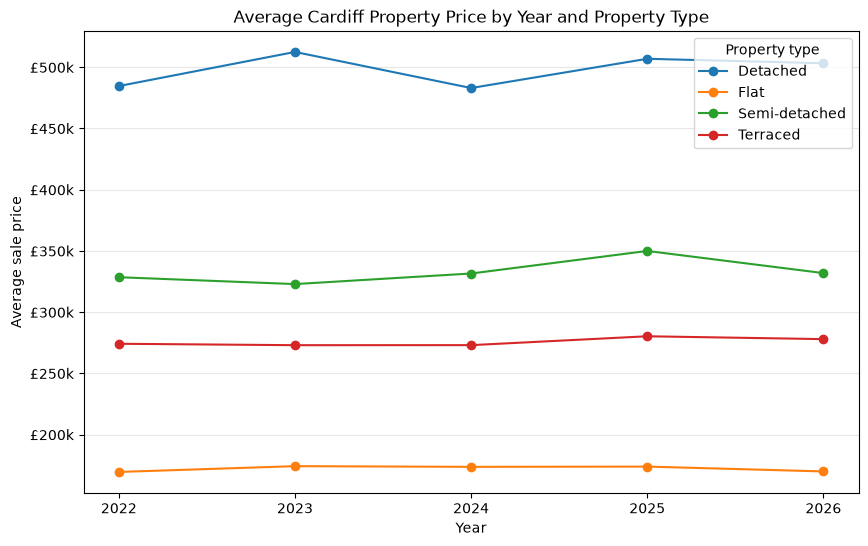

In [24]:
property_names = {
    "D": "Detached",
    "S": "Semi-detached",
    "T": "Terraced",
    "F": "Flat"
}

plot_df = house_gdf_epc.copy()

plot_df["property_type_name"] = (
    plot_df["property_type"].map(property_names)
)

average_price_year = (
    plot_df
    .groupby(
        ["year", "property_type_name"]
    )["price"]
    .mean()
    .unstack()
)

average_price_year

ax = average_price_year.plot(
    kind="line",
    marker="o",
    figsize=(10, 6)
)

ax.set_title(
    "Average Cardiff Property Price by Year and Property Type"
)

ax.set_xlabel("Year")
ax.set_ylabel("Average sale price")

ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f"£{value / 1000:.0f}k"
    )
)

plt.xticks(
    average_price_year.index,
    average_price_year.index.astype(int)
)

plt.legend(
    title="Property type"
)

plt.grid(
    axis="y",
    alpha=0.3
)


plt.show()


# 7. Model A — Without EPC


## 7.1 Define Model A features and train/test split


In [25]:
model_a_gdf = house_gdf_epc[
    house_gdf_epc["property_type"].isin(["D", "S", "T", "F"])
].copy()

model_a_gdf["log_adjusted_price"] = np.log(
    model_a_gdf["adjusted_price"]
)

categorical_features_a = [
    "property_type",
    "old_new",
    "duration",
    "ppd_category_type",
    "postcode_district",
    "distance_band",
    "sector",
    "school_type",
    "greenspace_function"
]

numeric_features_a = [
    "decimal_year",
    "latitude",
    "longitude",
    "distance_to_cardiff_centre_km",
    "distance_to_nearest_school_m",
    "distance_to_nearest_transport_m",
    "crime_count_1km_12m",
    "nearest_greenspace_distance_m",
    "any_flood_risk"
]

X_a = model_a_gdf[
    categorical_features_a + numeric_features_a
]

y_a = model_a_gdf["log_adjusted_price"]

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_a,
    y_a,
    test_size=0.2,
    random_state=1
)

print("Training houses:", len(X_train_a))
print("Testing houses:", len(X_test_a))


Training houses: 17507
Testing houses: 4377


## 7.2 Preprocessing and Random Forest


In [26]:
categorical_pipeline_a = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

numeric_pipeline_a = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

preprocessor_a = ColumnTransformer(
    transformers=[
        (
            "cat",
            categorical_pipeline_a,
            categorical_features_a
        ),
        (
            "num",
            numeric_pipeline_a,
            numeric_features_a
        )
    ]
)

model_a = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_a
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=500,
                max_depth=25,
                max_features=0.5,
                min_samples_split=2,
                min_samples_leaf=1,
                random_state=1,
                n_jobs=-1
            )
        )
    ]
)

model_a.fit(
    X_train_a,
    y_train_a
)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](18,)","['property_type','old_new','duration',...,'crime_count_1km_12m', 'nearest_greenspace_distance_m','any_flood_risk']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,18
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatic

## 7.3 Test-set evaluation


In [27]:
y_pred_log_a = model_a.predict(X_test_a)

y_test_actual_a = np.exp(y_test_a)
y_pred_actual_a = np.exp(y_pred_log_a)

mae_a = mean_absolute_error(
    y_test_actual_a,
    y_pred_actual_a
)

rmse_a = np.sqrt(
    mean_squared_error(
        y_test_actual_a,
        y_pred_actual_a
    )
)

r2_actual_a = r2_score(
    y_test_actual_a,
    y_pred_actual_a
)

r2_log_a = r2_score(
    y_test_a,
    y_pred_log_a
)

print(f"Model A MAE: £{mae_a:,.2f}")
print(f"Model A RMSE: £{rmse_a:,.2f}")
print(f"Model A R² actual: {r2_actual_a:.4f}")
print(f"Model A R² log: {r2_log_a:.4f}")


Model A MAE: £50,400.94
Model A RMSE: £100,420.83
Model A R² actual: 0.6596
Model A R² log: 0.7700


## 7.4 Cross-validation


In [28]:
def actual_mae_from_log(y_true_log, y_pred_log):
    y_true_actual = np.exp(y_true_log)
    y_pred_actual = np.exp(y_pred_log)

    return mean_absolute_error(
        y_true_actual,
        y_pred_actual
    )

actual_mae_scorer = make_scorer(
    actual_mae_from_log,
    greater_is_better=False
)

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=1
)

cv_results_a = cross_validate(
    model_a,
    X_a,
    y_a,
    cv=cv,
    scoring={
        "r2_log": "r2",
        "mae_actual": actual_mae_scorer
    },
    n_jobs=-1
)

print(
    "CV Log R²:",
    cv_results_a["test_r2_log"]
)

print(
    "Mean CV Log R²:",
    cv_results_a["test_r2_log"].mean()
)

print(
    "Mean CV MAE: £",
    -cv_results_a["test_mae_actual"].mean()
)


CV Log R²: [0.7694793  0.78701563 0.76742458 0.78257524 0.78402299]
Mean CV Log R²: 0.778103550383078
Mean CV MAE: £ 50846.111825217464


# 8. Model B — With EPC


## 8.1 Prepare matched dataset and EPC features


In [29]:
model_b_gdf = house_gdf_epc[
    house_gdf_epc["has_epc"] == True
].copy().reset_index(drop=True)

model_b_gdf["total_floor_area"] = pd.to_numeric(
    model_b_gdf["total_floor_area"],
    errors="coerce"
)

model_b_gdf["number_habitable_rooms"] = pd.to_numeric(
    model_b_gdf["number_habitable_rooms"],
    errors="coerce"
)

print("EPC-matched houses:", len(model_b_gdf))


categorical_epc_features = []

numeric_epc_features = [
    "total_floor_area",
    "number_habitable_rooms"
]

categorical_features_b = (
    categorical_features_a.copy()
)

numeric_features_b = (
    numeric_features_a
    + numeric_epc_features
)

X_a_matched = model_b_gdf[
    categorical_features_a
    + numeric_features_a
].copy()

X_b = model_b_gdf[
    categorical_features_b
    + numeric_features_b
].copy()

y_matched = model_b_gdf[
    "log_adjusted_price"
].copy()

print(
    "Model B features:",
    categorical_features_b
    + numeric_features_b
)


train_indices, test_indices = train_test_split(
    model_b_gdf.index,
    test_size=0.2,
    random_state=1
)

X_train_a_matched = X_a_matched.loc[
    train_indices
]

X_test_a_matched = X_a_matched.loc[
    test_indices
]

X_train_b = X_b.loc[
    train_indices
]

X_test_b = X_b.loc[
    test_indices
]

y_train_matched = y_matched.loc[
    train_indices
]

y_test_matched = y_matched.loc[
    test_indices
]

print("Training houses:", len(train_indices))
print("Testing houses:", len(test_indices))


EPC-matched houses: 10711
Model B features: ['property_type', 'old_new', 'duration', 'ppd_category_type', 'postcode_district', 'distance_band', 'sector', 'school_type', 'greenspace_function', 'decimal_year', 'latitude', 'longitude', 'distance_to_cardiff_centre_km', 'distance_to_nearest_school_m', 'distance_to_nearest_transport_m', 'crime_count_1km_12m', 'nearest_greenspace_distance_m', 'any_flood_risk', 'total_floor_area', 'number_habitable_rooms']
Training houses: 8568
Testing houses: 2143


## 8.2 Fit matched Model A and Model B


In [30]:
model_a_matched = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor_a)
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=500,
                max_depth=25,
                max_features=0.5,
                min_samples_split=2,
                min_samples_leaf=1,
                random_state=1,
                n_jobs=-1
            )
        )
    ]
)

model_a_matched.fit(
    X_train_a_matched,
    y_train_matched
)


preprocessor_b = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline(
                steps=[
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="most_frequent"
                        )
                    ),
                    (
                        "onehot",
                        OneHotEncoder(
                            handle_unknown="ignore"
                        )
                    )
                ]
            ),
            categorical_features_b
        ),
        (
            "num",
            Pipeline(
                steps=[
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="median"
                        )
                    )
                ]
            ),
            numeric_features_b
        )
    ]
)

model_b = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_b
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=500,
                max_depth=25,
                max_features=0.5,
                min_samples_split=2,
                min_samples_leaf=1,
                random_state=1,
                n_jobs=-1
            )
        )
    ]
)

model_b.fit(
    X_train_b,
    y_train_matched
)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['property_type','old_new','duration',...,'any_flood_risk', 'total_floor_area','number_habitable_rooms']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passe

## 8.3 Matched test-set comparison


In [31]:
pred_a_log = model_a_matched.predict(
    X_test_a_matched
)

pred_b_log = model_b.predict(
    X_test_b
)

actual_price = np.exp(
    y_test_matched
)

pred_a_price = np.exp(
    pred_a_log
)

pred_b_price = np.exp(
    pred_b_log
)


def evaluate_model(
    name,
    y_true_log,
    y_pred_log,
    y_true_price,
    y_pred_price
):
    mae = mean_absolute_error(
        y_true_price,
        y_pred_price
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true_price,
            y_pred_price
        )
    )

    r2_actual = r2_score(
        y_true_price,
        y_pred_price
    )

    r2_log = r2_score(
        y_true_log,
        y_pred_log
    )

    print(name)
    print(f"MAE: £{mae:,.2f}")
    print(f"RMSE: £{rmse:,.2f}")
    print(f"R² actual: {r2_actual:.4f}")
    print(f"R² log: {r2_log:.4f}")
    print()


evaluate_model(
    "Matched Model A — without EPC",
    y_test_matched,
    pred_a_log,
    actual_price,
    pred_a_price
)

evaluate_model(
    "Model B — floor area and rooms",
    y_test_matched,
    pred_b_log,
    actual_price,
    pred_b_price
)


Matched Model A — without EPC
MAE: £56,090.62
RMSE: £95,787.13
R² actual: 0.7329
R² log: 0.7749

Model B — floor area and rooms
MAE: £39,515.62
RMSE: £62,934.24
R² actual: 0.8847
R² log: 0.8632



## 8.4 Matched cross-validation comparison


In [32]:
cv_matched = KFold(
    n_splits=5,
    shuffle=True,
    random_state=1
)

cv_a_matched = cross_validate(
    model_a_matched,
    X_a_matched,
    y_matched,
    cv=cv_matched,
    scoring={
        "r2_log": "r2",
        "mae_actual": actual_mae_scorer
    },
    n_jobs=-1
)

cv_b_matched = cross_validate(
    model_b,
    X_b,
    y_matched,
    cv=cv_matched,
    scoring={
        "r2_log": "r2",
        "mae_actual": actual_mae_scorer
    },
    n_jobs=-1
)


print("Matched Model A")
print(
    "Mean CV Log R²:",
    cv_a_matched["test_r2_log"].mean()
)
print(
    "Mean CV MAE: £",
    -cv_a_matched["test_mae_actual"].mean()
)

print("\nModel B")
print(
    "Mean CV Log R²:",
    cv_b_matched["test_r2_log"].mean()
)
print(
    "Mean CV MAE: £",
    -cv_b_matched["test_mae_actual"].mean()
)


Matched Model A
Mean CV Log R²: 0.7699962904089206
Mean CV MAE: £ 56691.83451002317

Model B
Mean CV Log R²: 0.8500625485329589
Mean CV MAE: £ 41853.9014443797


## 8.5 Permutation importance for Model B


In [33]:
perm_b = permutation_importance(
    model_b,
    X_test_b,
    y_test_matched,
    scoring="r2",
    n_repeats=10,
    random_state=1,
    n_jobs=-1
)

importance_b = pd.DataFrame(
    {
        "feature": X_test_b.columns,
        "importance_mean": perm_b.importances_mean,
        "importance_std": perm_b.importances_std
    }
).sort_values(
    "importance_mean",
    ascending=False
)

importance_b.head(20)


,feature,importance_mean,importance_std
18,total_floor_area,0.545955,0.013598
0,property_type,0.094142,0.003241
10,latitude,0.075680,0.004397
11,longitude,0.066469,0.003813
19,number_habitable_rooms,0.035022,0.001824
2,duration,0.034667,0.002411
4,postcode_district,0.030951,0.002349
12,distance_to_cardiff_centre_km,0.017369,0.000808
3,ppd_category_type,0.006732,0.001092
1,old_new,0.004869,0.001017


# 9. Random Forest vs XGBoost


## 9.1 Model B pipelines


In [34]:
rf_model_b = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor_b)
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=500,
                max_depth=25,
                max_features=0.5,
                min_samples_split=2,
                min_samples_leaf=1,
                random_state=1,
                n_jobs=-1
            )
        )
    ]
)

xgb_model_b = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor_b)
        ),
        (
            "model",
            XGBRegressor(
                objective="reg:squarederror",
                eval_metric="rmse",
                n_estimators=500,
                learning_rate=0.03,
                max_depth=5,
                min_child_weight=3,
                subsample=0.8,
                colsample_bytree=0.8,
                reg_alpha=0.1,
                reg_lambda=1.0,
                tree_method="hist",
                random_state=1,
                n_jobs=-1
            )
        )
    ]
)

models_b = {
    "Random Forest": rf_model_b,
    "XGBoost": xgb_model_b
}


## 9.2 comparison


In [56]:
test_results_b = []
fitted_models_b = {}

for model_name, pipeline in models_b.items():

    pipeline.fit(
        X_train_b,
        y_train_matched
    )

    fitted_models_b[model_name] = pipeline

    train_prediction_log = pipeline.predict(
        X_train_b
    )

    test_prediction_log = pipeline.predict(
        X_test_b
    )

    train_actual_price = np.exp(
        y_train_matched
    )

    test_actual_price = np.exp(
        y_test_matched
    )

    train_prediction_price = np.exp(
        train_prediction_log
    )

    test_prediction_price = np.exp(
        test_prediction_log
    )

    train_r2_log = r2_score(
        y_train_matched,
        train_prediction_log
    )

    test_r2_log = r2_score(
        y_test_matched,
        test_prediction_log
    )

    test_r2_actual = r2_score(
        test_actual_price,
        test_prediction_price
    )

    test_mae = mean_absolute_error(
        test_actual_price,
        test_prediction_price
    )

    test_rmse = np.sqrt(
        mean_squared_error(
            test_actual_price,
            test_prediction_price
        )
    )

    test_results_b.append(
        {
            "Model": model_name,
            "Train R2 log": train_r2_log,
            "Test R2 log": test_r2_log,
            "Generalisation gap":
                train_r2_log - test_r2_log,
            "Test R2 actual": test_r2_actual,
            "Test MAE actual (£)": test_mae,
            "Test RMSE actual (£)": test_rmse
        }
    )

test_results_b = pd.DataFrame(
    test_results_b
)

display(
    test_results_b.round(
        {
            "Train R2 log": 4,
            "Test R2 log": 4,
            "Generalisation gap": 4,
            "Test R2 actual": 4,
            "Test MAE actual (£)": 2,
            "Test RMSE actual (£)": 2
        }
    )
)


,Model,Train R2 log,Test R2 log,Generalisation gap,Test R2 actual,Test MAE actual (£),Test RMSE actual (£)
0,Random Forest,0.9756,0.8632,0.1124,0.8847,39515.62,62934.24
1,XGBoost,0.9062,0.8642,0.0420,0.8844,40330.29,63026.99


## 9.3 Cross-validation comparison


In [62]:
cv_b = KFold(
    n_splits=5,
    shuffle=True,
    random_state=1
)

scoring_b = {
    "r2_log": "r2",
    "mae_actual": actual_mae_scorer
}

cv_results_b = {}
cv_summary_b = []

for model_name, pipeline in models_b.items():


    results = cross_validate(
        clone(pipeline),
        X_train_b,
        y_train_matched,
        cv=cv_b,
        scoring=scoring_b,
        return_train_score=True,
        n_jobs=1
    )

    cv_results_b[model_name] = results

    mean_train_r2 = (
        results["train_r2_log"].mean()
    )

    mean_test_r2 = (
        results["test_r2_log"].mean()
    )

    mean_cv_mae = (
        -results["test_mae_actual"].mean()
    )

    cv_summary_b.append(
        {
            "Model": model_name,
            "Mean CV train R2 log":
                mean_train_r2,
            "Mean CV R2 log":
                mean_test_r2,
            "CV R2 standard deviation":
                results["test_r2_log"].std(),
            "CV generalisation gap":
                mean_train_r2 - mean_test_r2,
            "Mean CV MAE actual (£)":
                mean_cv_mae,
            "CV MAE standard deviation (£)":
                results["test_mae_actual"].std(),
            "Mean fit time":
                results["fit_time"].mean()
        }
    )

cv_summary_b = pd.DataFrame(
    cv_summary_b
)



for model_name in cv_results_b:
    print(f"\n{model_name}")

    print(
        "Fold R² log:",
        np.round(
            cv_results_b[model_name][
                "test_r2_log"
            ],
            4
        )
    )

    print(
        "Fold MAE actual (£):",
        np.round(
            -cv_results_b[model_name][
                "test_mae_actual"
            ],
            2
        )
    )


complete_comparison_b = test_results_b.merge(
    cv_summary_b,
    on="Model",
    how="left"
)

complete_comparison_b = (
    complete_comparison_b
    .sort_values(
        "Mean CV MAE actual (£)",
        ascending=True
    )
    .reset_index(drop=True)
)

display(
    complete_comparison_b.round(
        {
            "Train R2 log": 4,
            "Test R2 log": 4,
            "Generalisation gap": 4,
            "Test R2 actual": 4,
            "Test MAE actual (£)": 2,
            "Test RMSE actual (£)": 2,
            "Mean CV train R2 log": 4,
            "Mean CV R2 log": 4,
            "CV R2 standard deviation": 4,
            "CV generalisation gap": 4,
            "Mean CV MAE actual (£)": 2,
            "CV MAE standard deviation (£)": 2,
            "Mean fit time": 2
        }
    )
)



Random Forest
Fold R² log: [0.8612 0.8093 0.8175 0.8612 0.8654]
Fold MAE actual (£): [39976.16 50879.06 44124.46 42926.72 38644.3 ]

XGBoost
Fold R² log: [0.8592 0.8136 0.8442 0.8663 0.8653]
Fold MAE actual (£): [41094.91 50671.44 41568.26 42459.64 40388.95]


,Model,Train R2 log,Test R2 log,Generalisation gap,Test R2 actual,Test MAE actual (£),Test RMSE actual (£),Mean CV train R2 log,Mean CV R2 log,CV R2 standard deviation,CV generalisation gap,Mean CV MAE actual (£),CV MAE standard deviation (£),Mean fit time
0,XGBoost,0.9062,0.8642,0.0420,0.8844,40330.29,63026.99,0.9128,0.8497,0.0197,0.0631,43236.64,3777.83,0.74
1,Random Forest,0.9756,0.8632,0.1124,0.8847,39515.62,62934.24,0.9760,0.8429,0.0243,0.1331,43310.14,4265.77,1.18


## 9.4 Select and fit final Model B on all matched data


In [37]:
best_model_name_b = (
    complete_comparison_b
    .iloc[0]["Model"]
)

final_model_b = clone(
    models_b[best_model_name_b]
)

final_model_b.fit(
    X_b,
    y_matched
)

print(
    "Selected final Model B:",
    best_model_name_b
)

print(
    "Mean CV MAE: £",
    round(
        complete_comparison_b.iloc[0][
            "Mean CV MAE actual (£)"
        ],
        2
    )
)

print(
    "Mean CV R² log:",
    round(
        complete_comparison_b.iloc[0][
            "Mean CV R2 log"
        ],
        4
    )
)


Selected final Model B: XGBoost
Mean CV MAE: £ 43236.64
Mean CV R² log: 0.8497


# 10. Global SHAP Interpretation


## 10.1 Prepare SHAP values for the selected model


In [38]:
best_pipeline_b = fitted_models_b[
    best_model_name_b
]


def prepare_tree_shap(fitted_pipeline, X_test):

    fitted_preprocessor = (
        fitted_pipeline.named_steps['preprocessor']
    )

    fitted_tree_model = (
        fitted_pipeline.named_steps['model']
    )

    X_test_processed = (
        fitted_preprocessor.transform(X_test)
    )

    if hasattr(X_test_processed, 'toarray'):
        X_test_processed = X_test_processed.toarray()


    feature_name = (
        fitted_preprocessor.get_feature_names_out()
    )

    X_test_processed_df = pd.DataFrame(
        X_test_processed,
        columns = feature_name,
        index = X_test.index
    )

    explainer = shap.TreeExplainer(
        fitted_tree_model
    )

    shap_values = explainer(
        X_test_processed_df
    )

    return (
        X_test_processed_df,
        explainer,
        shap_values
    )

(
    X_test_b_processed,
    explainer_b,
    shap_values_b
) = prepare_tree_shap(
    best_pipeline_b,
    X_test_b
)


## 10.2 SHAP summary plot


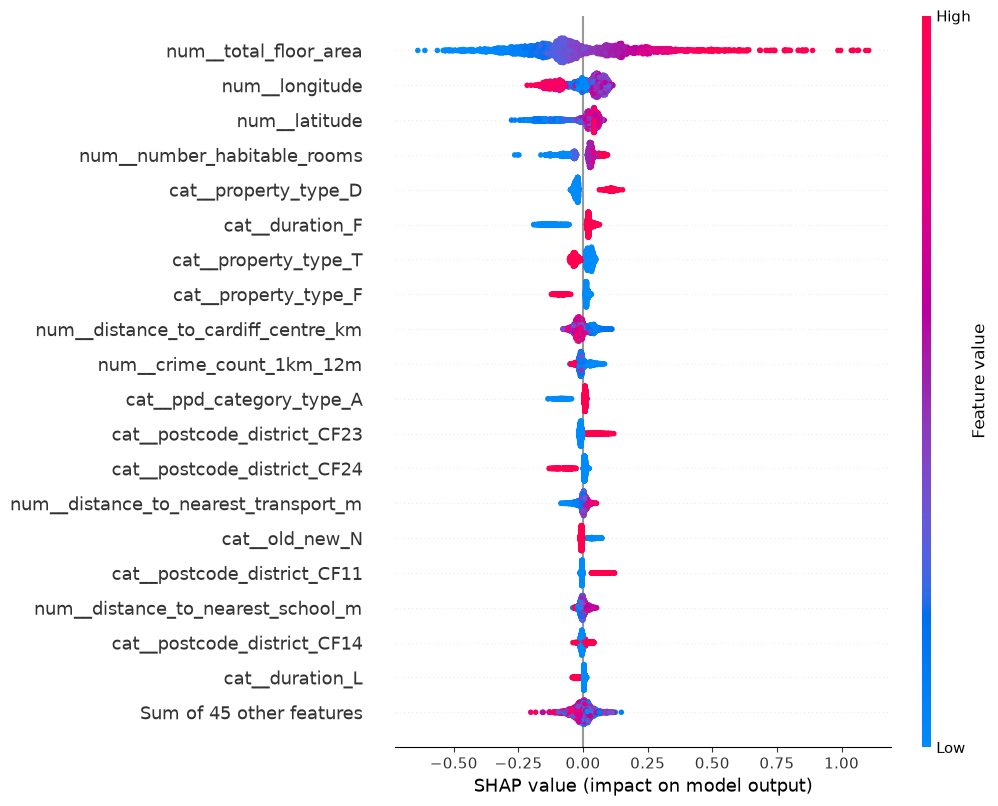

<Figure size 640x480 with 0 Axes>

In [39]:
shap.plots.beeswarm(
    shap_values_b,
    max_display = 20
)

plt.tight_layout()
plt.show()


# 11. Export Final Model Artifacts


The files exported here are the minimum model artifacts needed by the prediction prototype:
- trained model pipeline,
- model configuration and HPI reference information,
- postcode lookup,
- HPI lookup.


In [40]:
joblib.dump(
    final_model_b,
    model_folder / "model_b_floor_area_rooms.joblib",
)

model_start_month = (
    house_gdf_epc["sale_month"].min()
)
model_end_month = (
    house_gdf_epc["sale_month"].max()
)

best_cv_row = complete_comparison_b.loc[
    complete_comparison_b["Model"] == best_model_name_b
].iloc[0]

model_configuration = {
    "selected_model": str(best_model_name_b),
    "target": "log_adjusted_price",
    "categorical_features": categorical_features_b,
    "numeric_features": numeric_features_b,
    "epc_features": numeric_epc_features,
    "model_start_month": model_start_month.strftime("%Y-%m-%d"),
    "model_end_month": model_end_month.strftime("%Y-%m-%d"),
    "reference_month": reference_month.strftime("%Y-%m-%d"),
    "reference_hpi": (
        reference_hpi
        .set_index("property_type")["reference_hpi"]
        .astype(float)
        .to_dict()
    ),
    "mean_cv_mae_actual": float(
        best_cv_row["Mean CV MAE actual (£)"]
    ),
    "mean_cv_r2_log": float(
        best_cv_row["Mean CV R2 log"]
    ),
}

with open(
    model_folder / "model_b_floor_area_rooms_features.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        model_configuration,
        file,
        indent=4,
    )

postcode_lookup = (
    postcode_df_clean[
        ["postcode", "latitude", "longitude"]
    ]
    .drop_duplicates(subset="postcode")
    .reset_index(drop=True)
)

postcode_lookup.to_csv(
    model_folder / "postcode_lookup.csv",
    index=False,
)

hpi_lookup = hpi_long.loc[
    hpi_long["period"].between(
        model_start_month,
        model_end_month,
    ),
    ["period", "property_type", "hpi_at_sale"],
].copy()

hpi_lookup.to_csv(
    model_folder / "hpi_lookup.csv",
    index=False,
)

print("Saved model artifacts:")
for path in sorted(model_folder.iterdir()):
    print(" -", path.name)


Saved model artifacts:
 - hpi_lookup.csv
 - model_b_floor_area_rooms.joblib
 - model_b_floor_area_rooms_features.json
 - postcode_lookup.csv


# 12. Property-Value Prediction Prototype


## 12.1 Load exported model, configuration and lookup tables


In [41]:
# 1. Load the trained model

prediction_model = joblib.load(
    model_folder / "model_b_floor_area_rooms.joblib"
)


# 2. Load the model configuration

with open(
    model_folder / "model_b_floor_area_rooms_features.json",
    "r",
    encoding="utf-8"
) as file:
    model_configuration = json.load(file)

categorical_features_b = (
    model_configuration["categorical_features"]
)

numeric_features_b = (
    model_configuration["numeric_features"]
)

reference_month = pd.Timestamp(
    model_configuration["reference_month"]
)

reference_hpi_lookup = (
    model_configuration["reference_hpi"]
)


# 3. Load postcode and HPI lookup tables

postcode_lookup = pd.read_csv(
    model_folder / "postcode_lookup.csv"
)

hpi_lookup = pd.read_csv(
    model_folder / "hpi_lookup.csv",
    parse_dates=["period"]
)



prediction_margin_reference = float(
    model_configuration["mean_cv_mae_actual"]
)


## 12.2 Enter property details and create the input location


In [42]:
# 4. Enter and find the postcode

entered_postcode = (
    input("Enter postcode: ")
    .upper()
    .strip()
    .replace(" ", "")
)

postcode_match = postcode_lookup.loc[
    postcode_lookup["postcode"]
    == entered_postcode
]

if postcode_match.empty:
    raise ValueError(
        f"Postcode '{entered_postcode}' was not found."
    )

entered_latitude = (
    postcode_match.iloc[0]["latitude"]
)

entered_longitude = (
    postcode_match.iloc[0]["longitude"]
)


# 5. Enter the prediction date

entered_year = int(
    input("Enter sale year: ")
)

entered_month = int(
    input("Enter sale month (1-12): ")
)

if entered_month < 1 or entered_month > 12:
    raise ValueError(
        "Month must be between 1 and 12."
    )

entered_prediction_date = pd.Timestamp(
    year=entered_year,
    month=entered_month,
    day=1
)

minimum_prediction_date = (
    hpi_lookup["period"].min()
)

maximum_prediction_date = (
    hpi_lookup["period"].max()
)

if not (
    minimum_prediction_date
    <= entered_prediction_date
    <= maximum_prediction_date
):
    raise ValueError(
        "Enter a date between "
        f"{minimum_prediction_date:%B %Y} and "
        f"{maximum_prediction_date:%B %Y}."
    )

entered_decimal_year = (
    entered_year
    + (entered_month - 1) / 12
)


# 6. Enter property information

entered_property_type = (
    input("Property type (D/S/T/F): ")
    .upper()
    .strip()
)

entered_old_new = (
    input("New build (Y/N): ")
    .upper()
    .strip()
)

entered_duration = (
    input("Duration (F/L): ")
    .upper()
    .strip()
)

entered_sale_category = (
    input(
        "Sale category "
        "(A = standard, B = additional): "
    )
    .upper()
    .strip()
)

entered_total_floor_area = float(
    input(
        "Total floor area in square metres: "
    )
)

entered_number_rooms = int(
    input(
        "Number of habitable rooms: "
    )
)


# 7. Extract the postcode district

entered_postcode_district = (
    pd.Series(
        [entered_postcode]
    )
    .str.extract(
        r"^([A-Z]{1,2}\d[A-Z\d]?)",
        expand=False
    )
    .iloc[0]
)


# 8. Create the property location

entered_house_location = gpd.GeoDataFrame(
    {
        "postcode": [
            entered_postcode
        ],
        "property_type": [
            entered_property_type
        ],
        "old_new": [
            entered_old_new
        ],
        "duration": [
            entered_duration
        ],
        "ppd_category_type": [
            entered_sale_category
        ],
        "postcode_district": [
            entered_postcode_district
        ],
        "decimal_year": [
            entered_decimal_year
        ],
        "latitude": [
            entered_latitude
        ],
        "longitude": [
            entered_longitude
        ],
        "total_floor_area": [
            entered_total_floor_area
        ],
        "number_habitable_rooms": [
            entered_number_rooms
        ]
    },
    geometry=gpd.points_from_xy(
        [entered_longitude],
        [entered_latitude]
    ),
    crs="EPSG:4326"
)


# 9. Convert to British National Grid

entered_house_location = (
    entered_house_location.to_crs(
        "EPSG:27700"
    )
)


# 10. Display the entered property information

display(
    entered_house_location.drop(
        columns="geometry"
    )
)


,postcode,property_type,old_new,duration,ppd_category_type,postcode_district,decimal_year,latitude,longitude,total_floor_area,number_habitable_rooms
0,CF244HJ,T,N,F,A,CF24,2026.25,51.495049,-3.189338,70.0,3


## 12.3 Cardiff-centre distance


In [43]:
cardiff_latitude = 51.4816
cardiff_longitude = -3.1791


def haversine(
    latitude_1,
    longitude_1,
    latitude_2,
    longitude_2
):
    earth_radius_km = 6371

    latitude_1 = np.radians(latitude_1)
    longitude_1 = np.radians(longitude_1)
    latitude_2 = np.radians(latitude_2)
    longitude_2 = np.radians(longitude_2)

    latitude_difference = latitude_2 - latitude_1
    longitude_difference = longitude_2 - longitude_1

    a = (
        np.sin(latitude_difference / 2) ** 2
        + np.cos(latitude_1)
        * np.cos(latitude_2)
        * np.sin(longitude_difference / 2) ** 2
    )

    c = 2 * np.arctan2(
        np.sqrt(a),
        np.sqrt(1 - a)
    )

    return earth_radius_km * c


def create_distance_band(distance_km):
    if distance_km < 2:
        return "0-2km"
    if distance_km < 5:
        return "2-5km"
    if distance_km < 10:
        return "5-10km"
    if distance_km <= 20:
        return "10-20km"
    return "20km+"



entered_house_location["distance_to_cardiff_centre_km"] = haversine(
    entered_house_location["latitude"],
    entered_house_location["longitude"],
    cardiff_latitude,
    cardiff_longitude
)

entered_house_location["distance_band"] = (
    entered_house_location["distance_to_cardiff_centre_km"]
    .apply(create_distance_band)
)


## 12.4 Nearest school, transport and greenspace


In [44]:
entered_house_location = (
    entered_house_location.drop(
        columns="index_right",
        errors="ignore"
    )
)

entered_house_location = gpd.sjoin_nearest(
    entered_house_location,
    cardiff_school_gdf[
        [
            "school_name",
            "sector",
            "school_type",
            "geometry"
        ]
    ],
    how="left",
    distance_col=
        "distance_to_nearest_school_m"
)

entered_house_location = (
    entered_house_location
    .sort_values(
        "distance_to_nearest_school_m"
    )
    .head(1)
    .drop(
        columns="index_right",
        errors="ignore"
    )
    .reset_index(drop=True)
)

entered_house_location = (
    entered_house_location.drop(
        columns="index_right",
        errors="ignore"
    )
)

entered_house_location = gpd.sjoin_nearest(
    entered_house_location,
    transport_gdf[
        [
            "commonname",
            "geometry"
        ]
    ],
    how="left",
    distance_col=
        "distance_to_nearest_transport_m"
)

entered_house_location = (
    entered_house_location
    .sort_values(
        "distance_to_nearest_transport_m"
    )
    .head(1)
    .drop(
        columns="index_right",
        errors="ignore"
    )
    .reset_index(drop=True)
)

entered_house_location = (
    entered_house_location.drop(
        columns="index_right",
        errors="ignore"
    )
)

entered_house_location = gpd.sjoin_nearest(
    entered_house_location,
    greenspace_sites[
        [
            "greenspace_name",
            "greenspace_function",
            "geometry"
        ]
    ],
    how="left",
    distance_col=
        "nearest_greenspace_distance_m"
)

entered_house_location = (
    entered_house_location
    .sort_values(
        "nearest_greenspace_distance_m"
    )
    .head(1)
    .drop(
        columns="index_right",
        errors="ignore"
    )
    .reset_index(drop=True)
)

display(
    entered_house_location[
        [
            "postcode",
            "school_name",
            "distance_to_nearest_school_m",
            "commonname",
            "distance_to_nearest_transport_m",
            "greenspace_name",
            "greenspace_function",
            "nearest_greenspace_distance_m"
        ]
    ]
)


,postcode,school_name,distance_to_nearest_school_m,commonname,distance_to_nearest_transport_m,greenspace_name,greenspace_function,nearest_greenspace_distance_m
0,CF244HJ,Cathays High School,442.82933,Gelligaer Gardens,96.263714,Maindy Centre,Other Sports Facility,110.62597


## 12.5 Crime count for the preceding 12 complete months


In [45]:
crime_gdf = gpd.read_file(
    crime_gpkg_path
)

crime_gdf["date"] = pd.to_datetime(
    crime_gdf["date"],
    errors="coerce"
)

crime_gdf = crime_gdf.dropna(
    subset=[
        "date",
        "geometry"
    ]
).reset_index(drop=True)

crime_gdf["crime_id"] = (
    crime_gdf.index
)

crime_gdf["crime_month"] = (
    crime_gdf["date"]
    .dt.to_period("M")
)

prediction_month = (
    entered_prediction_date.to_period("M")
)

crime_start_month = (
    prediction_month - 12
)

crime_end_month = (
    prediction_month - 1
)

crime_during_period = crime_gdf.loc[
    crime_gdf["crime_month"].between(
        crime_start_month,
        crime_end_month
    ),
    [
        "crime_id",
        "geometry"
    ]
].copy()

crime_during_period = (
    crime_during_period.to_crs(
        entered_house_location.crs
    )
)

entered_house_buffer = (
    entered_house_location[
        ["geometry"]
    ].copy()
)

entered_house_buffer["geometry"] = (
    entered_house_buffer
    .geometry
    .buffer(1000)
)

nearby_crimes = gpd.sjoin(
    crime_during_period,
    entered_house_buffer,
    how="inner",
    predicate="within"
)

entered_house_location[
    "crime_count_1km_12m"
] = (
    nearby_crimes["crime_id"].nunique()
)

print(
    "Crime count within 1 km:",
    entered_house_location[
        "crime_count_1km_12m"
    ].iloc[0]
)


Crime count within 1 km: 1686


## 12.6 Flood-risk flags


In [46]:
river_flood_gdf = (
    gpd.read_file(
        river_path
    )
    .to_crs(
        entered_house_location.crs
    )
)

sea_flood_gdf = (
    gpd.read_file(
        sea_path
    )
    .to_crs(
        entered_house_location.crs
    )
)

surface_flood_gdf = (
    gpd.read_file(
        surface_path
    )
    .to_crs(
        entered_house_location.crs
    )
)


def check_flood_risk(
    new_house_gdf,
    flood_gdf
):
    flood_join = gpd.sjoin(
        new_house_gdf[
            ["geometry"]
        ].drop(
            columns="index_right",
            errors="ignore"
        ),
        flood_gdf[
            ["geometry"]
        ],
        how="left",
        predicate="intersects"
    )

    return int(
        flood_join["index_right"]
        .notna()
        .any()
    )


river_risk = check_flood_risk(
    entered_house_location,
    river_flood_gdf
)

sea_risk = check_flood_risk(
    entered_house_location,
    sea_flood_gdf
)

surface_risk = check_flood_risk(
    entered_house_location,
    surface_flood_gdf
)

entered_house_location[
    "any_flood_risk"
] = int(
    river_risk == 1
    or sea_risk == 1
    or surface_risk == 1
)

print("River flood risk:", river_risk)
print("Sea flood risk:", sea_risk)
print(
    "Surface-water flood risk:",
    surface_risk
)
print(
    "Any flood risk:",
    entered_house_location[
        "any_flood_risk"
    ].iloc[0]
)


River flood risk: 0
Sea flood risk: 0
Surface-water flood risk: 0
Any flood risk: 0


## 12.7 Predict price for the entered month


In [47]:
required_features = (
    categorical_features_b
    + numeric_features_b
)

missing_features = [
    column
    for column in required_features
    if column
    not in entered_house_location.columns
]

if missing_features:
    raise ValueError(
        f"Missing features: {missing_features}"
    )

input_data_b = (
    entered_house_location[
        required_features
    ].copy()
)

predicted_log_price = (
    prediction_model.predict(
        input_data_b
    )[0]
)

predicted_adjusted_price = np.exp(
    predicted_log_price
)

entered_hpi_match = hpi_lookup.loc[
    (
        hpi_lookup["period"]
        == entered_prediction_date
    )
    &
    (
        hpi_lookup["property_type"]
        == entered_property_type
    )
]

if entered_hpi_match.empty:
    raise ValueError(
        "No HPI value was found for the "
        "entered date and property type."
    )

entered_month_hpi = (
    entered_hpi_match.iloc[0][
        "hpi_at_sale"
    ]
)

property_reference_hpi = float(
    reference_hpi_lookup[
        entered_property_type
    ]
)

predicted_price = (
    predicted_adjusted_price
    * entered_month_hpi
    / property_reference_hpi
)


hpi_scale = (
    entered_month_hpi
    / property_reference_hpi
)

prediction_margin_entered = (
    prediction_margin_reference
    * hpi_scale
)

lower_price = max(
    0,
    predicted_price - prediction_margin_entered,
)

upper_price = (
    predicted_price + prediction_margin_entered
)

print(
    f"Estimated property value for "
    f"{entered_prediction_date:%B %Y}: "
    f"£{predicted_price:,.2f}"
)

print(
    f"Estimated price range: "
    f"£{lower_price:,.2f} to £{upper_price:,.2f}"
)

print(
    f"Model reference-month equivalent "
    f"({reference_month:%B %Y}): "
    f"£{predicted_adjusted_price:,.2f}"
)

display(
    entered_house_location[
        [
            "postcode",
            "school_name",
            "commonname",
            "greenspace_name",
            "crime_count_1km_12m",
            "any_flood_risk",
            "total_floor_area",
            "number_habitable_rooms",
        ]
    ]
)


Estimated property value for April 2026: £261,322.67
Estimated price range: £218,581.58 to £304,063.76
Model reference-month equivalent (May 2026): £264,352.50


,postcode,school_name,commonname,greenspace_name,crime_count_1km_12m,any_flood_risk,total_floor_area,number_habitable_rooms
0,CF244HJ,Cathays High School,Gelligaer Gardens,Maindy Centre,1686,0,70.0,3


## 12.8 Three nearest EPC-matched comparable transactions


In [48]:
nearest_house= (gpd.sjoin_nearest(
    house_gdf_epc,
    entered_house_location[['geometry']],
    how='left',
    distance_col='nearest'
).sort_values(by = 'nearest', ascending=True))
nearest_house = nearest_house[nearest_house['has_epc'] == True].head(3)

nearest_house


,price,date_of_transfer,postcode,property_type,old_new,duration,paon,saon,street,locality,...,match_method,has_epc,sale_month,hpi_at_sale,reference_hpi,adjusted_price,log_adjusted_price,decimal_year,index_right,nearest
13818,265000,2024-05-10,CF244HN,T,N,F,127,NaN,MAINDY ROAD,NaN,...,normal_address,True,2024-05-01,97.9,104.7,283406.537283,12.554638,2024.333333,0,75.932155
8048,285000,2023-06-01,CF244HN,T,N,F,123,NaN,MAINDY ROAD,NaN,...,normal_address,True,2023-06-01,97.5,104.7,306046.153846,12.631491,2023.416667,0,75.932155
9119,240000,2023-09-28,CF244HN,T,N,F,131,NaN,MAINDY ROAD,NaN,...,normal_address,True,2023-09-01,99.3,104.7,253051.359517,12.441348,2023.666667,0,75.932155


# 13. Local SHAP Explanation for the Entered Property


## 13.1 Local SHAP waterfall


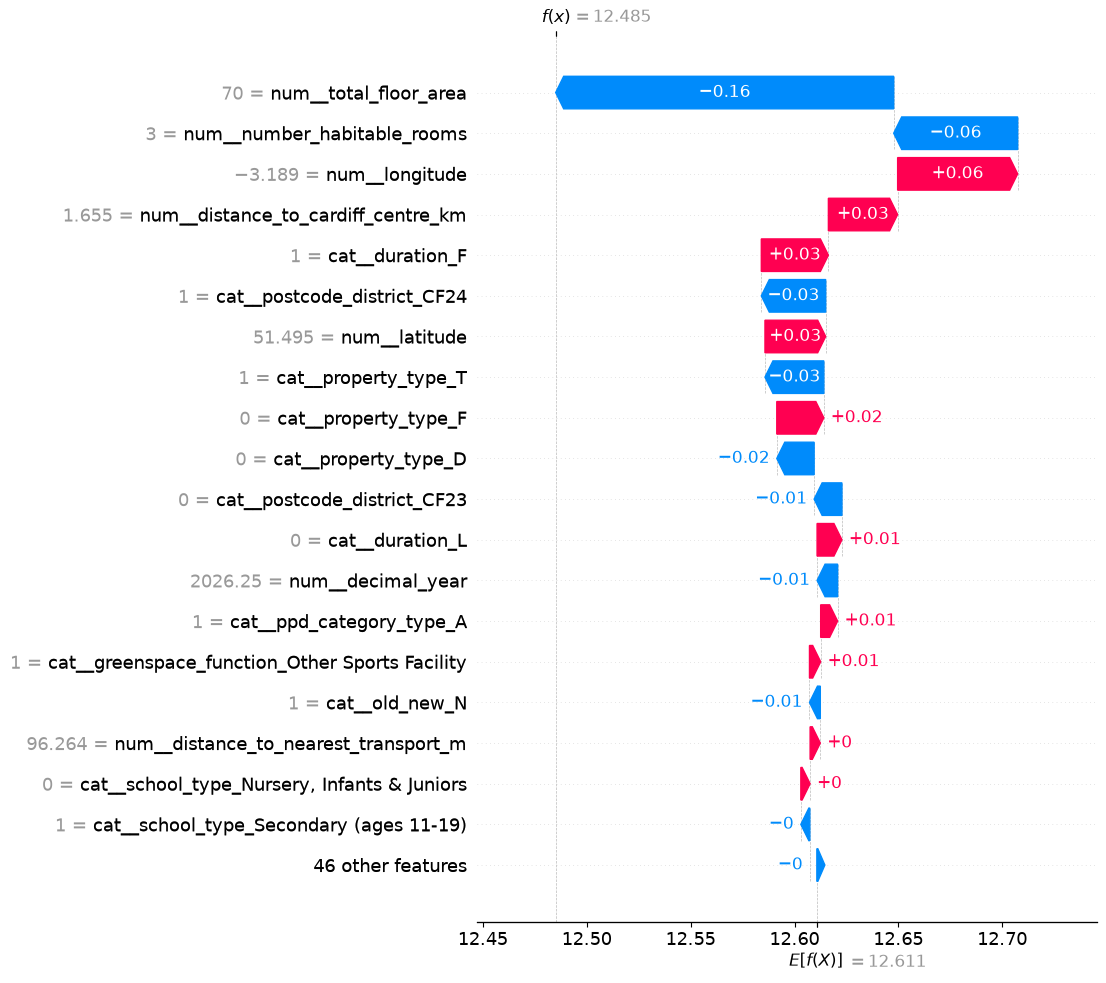

In [49]:
(
    processed_entered,
    explainer_b_entered,
    shap_values_b_entered,
) = prepare_tree_shap(
    prediction_model,
    input_data_b,
)

shap.plots.waterfall(
    shap_values_b_entered[0],
    max_display=20,
)
plt.show()


## 13.2 Importance features



In [50]:
feature_names = [
    name
    .replace("num__", "")
    .replace("cat__", "")
    for name in shap_values_b_entered[0].feature_names
]

shap_df = pd.DataFrame(
    {
        "features": feature_names,
        "value": shap_values_b_entered[0].data,
        "shap_value": shap_values_b_entered[0].values,
    }
)

shap_df["importance"] = (
    shap_df["shap_value"].abs()
)

shap_df = shap_df.sort_values(
    "importance",
    ascending=False,
)

grouped_rows = []

for feature in categorical_features_b:
    mask = shap_df["features"].str.startswith(
        feature + "_"
    )

    grouped_rows.append(
        {
            "features": feature,
            "value": input_data_b[feature].iloc[0],
            "shap_value": shap_df.loc[
                mask,
                "shap_value",
            ].sum(),
        }
    )

categorical_shap_df = pd.DataFrame(
    grouped_rows
)

numeric_shap_df = shap_df.loc[
    shap_df["features"].isin(numeric_features_b),
    ["features", "value", "shap_value"],
].copy()

location_shap = shap_df.loc[
    shap_df["features"].isin(
        ["longitude", "latitude"]
    ),
    "shap_value",
].sum()

final_shap_df = pd.concat(
    [
        numeric_shap_df,
        categorical_shap_df,
    ],
    ignore_index=True,
)

final_shap_df = final_shap_df.loc[
    ~final_shap_df["features"].isin(
        ["latitude", "longitude"]
    )
].copy()

location_row = pd.DataFrame(
    {
        "features": ["geographic_location"],
        "value": ["Cardiff location"],
        "shap_value": [location_shap],
    }
)

final_shap_df = pd.concat(
    [
        final_shap_df,
        location_row,
    ],
    ignore_index=True,
)

final_shap_df["importance"] = (
    final_shap_df["shap_value"].abs()
)

final_shap_df = (
    final_shap_df
    .sort_values(
        "importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

positive_factors = (
    final_shap_df.loc[
        final_shap_df["shap_value"] > 0
    ]
    .head(5)
)

negative_factors = (
    final_shap_df.loc[
        final_shap_df["shap_value"] < 0
    ]
    .head(5)
)

final_shap_df


,features,value,shap_value,importance
0,total_floor_area,70.0,-0.162717,0.162717
1,geographic_location,Cardiff location,0.087021,0.087021
2,number_habitable_rooms,3.0,-0.059681,0.059681
3,postcode_district,CF24,-0.046441,0.046441
4,duration,F,0.044255,0.044255
5,distance_to_cardiff_centre_km,1.654958,0.033337,0.033337
6,property_type,T,-0.026321,0.026321
7,ppd_category_type,A,0.010162,0.010162
8,decimal_year,2026.25,-0.009892,0.009892
9,old_new,N,-0.006226,0.006226


## 13.3 Readable explanation


In [78]:
feature_labels = {
    "total_floor_area": "Total floor area",
    "number_habitable_rooms": "Number of habitable rooms",
    "property_type": "Property type",
    "duration": "Tenure",
    "postcode_district": "Postcode district",
    "distance_to_cardiff_centre_km": "Distance to Cardiff centre",
    "distance_to_nearest_school_m": "Distance to nearest school",
    "distance_to_nearest_transport_m": "Distance to nearest transport",
    "nearest_greenspace_distance_m": "Distance to nearest greenspace",
    "crime_count_1km_12m": "Local crime count",
    "ppd_category_type" : "Price Paid Type",
    "geographic_location" : "Geographic location"
}

value_labels = {
    "property_type": {
        "D": "Detached",
        "S": "Semi-detached",
        "T": "Terraced",
        "F": "Flat"
    },

    "duration": {
        "F": "Freehold",
        "L": "Leasehold"
    },

    "ppd_category_type": {
        "A" : "Standard Price Paid",
        "B" : "Additional Price Paid"
    }
}

def format_shap_row(row):

    feature = row['features']
    value = row['value']

    feature_names = feature_labels.get(feature, feature.replace('_', ' ').title())

    if feature == "geographic_location":
        return "Geographic location"

    if feature in value_labels:
        value = value_labels[feature].get(value, value)

    if feature == 'total_floor_area':
        value = f'{value:.0f} m²'

    elif feature.startswith('distance_to') and feature.endswith('km'):
        value = f'{value:.2f} km'

    elif feature.startswith('distance_to') and feature.endswith('m'):
        value = f'{value:.0f} m'

    elif feature == 'number_habitable_rooms':
        value = f'{value:.0f}'

    return(f'{feature_names} : {value}')




print("CURRENT PROPERTY VALUE ESTIMATE")
print(
    f"\nPrediction month: "
    f"{entered_prediction_date:%B %Y}"
)
print(
    f"Estimated property value: "
    f"£{predicted_price:,.2f}"
)
print(
    f"Estimated price range: "
    f"£{lower_price:,.2f} to £{upper_price:,.2f}"
)

print(
    f"Model reference-month equivalent "
    f"({reference_month:%B %Y}): "
    f"£{predicted_adjusted_price:,.2f}"
)

print("\nFactors increasing the predicted value:")
for _, row in positive_factors.iterrows():
    print(format_shap_row(row))

print("\nFactors decreasing the predicted value:")
for _, row in negative_factors.iterrows():
    print(format_shap_row(row))


CURRENT PROPERTY VALUE ESTIMATE

Prediction month: April 2026
Estimated property value: £261,322.67
Estimated price range: £218,581.58 to £304,063.76
Model reference-month equivalent (May 2026): £264,352.50

Factors increasing the predicted value:
Geographic location
Tenure : Freehold
Distance to Cardiff centre : 1.65 km
Price Paid Type : Standard Price Paid
Greenspace Function : Other Sports Facility

Factors decreasing the predicted value:
Total floor area : 70 m²
Number of habitable rooms : 3
Postcode district : CF24
Property type : Terraced
Decimal Year : 2026.25
